In [3]:
!pip install ultralytics -q
!pip install torchvision -q
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.5 MB/s eta 0:00:00
Done!


In [1]:
# Unzip the dataset
import zipfile
import os

with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/potato_dataset')

print("Done! Let's see the folders:")
print(os.listdir('/content/potato_dataset'))

Done! Let's see the folders:
['PLD_3_Classes_256']


In [2]:
# See what's inside
import os

base = '/content/potato_dataset/PLD_3_Classes_256'
print(os.listdir(base))


for folder in os.listdir(base):
    path = os.path.join(base, folder)
    if os.path.isdir(path):
        print(f"\n{folder}:")
        print(os.listdir(path))

['Validation', 'Training', 'Testing']

Validation:
['Early_Blight', 'Healthy', 'Late_Blight']

Training:
['Early_Blight', 'Healthy', 'Late_Blight']

Testing:
['Early_Blight', 'Healthy', 'Late_Blight']


In [4]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


In [5]:
base = '/content/potato_dataset/PLD_3_Classes_256'

train_dir = os.path.join(base, 'Training')
val_dir   = os.path.join(base, 'Validation')
test_dir  = os.path.join(base, 'Testing')

classes = sorted(os.listdir(train_dir))
print("Classes found:", classes)
num_classes = len(classes) + 1  # +1 for background
print("Num classes (with background):", num_classes)

Classes found: ['Early_Blight', 'Healthy', 'Late_Blight']
Num classes (with background): 4


In [6]:
test_images = []
test_labels = []

for label, cls in enumerate(classes):
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        for img_file in os.listdir(cls_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_images.append(os.path.join(cls_path, img_file))
                test_labels.append(label + 1)  # +1 for background

print(f"Total test images: {len(test_images)}")
print(f"Sample: {test_images[0]}")

Total test images: 405
Sample: /content/potato_dataset/PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_125.jpg


In [7]:
def get_faster_rcnn_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

frcnn_model = get_faster_rcnn_model(num_classes)
frcnn_model = frcnn_model.to(device)
frcnn_model.eval()
print("Faster R-CNN model ready!")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 76.4MB/s]


Faster R-CNN model ready!


In [8]:
yolo_model = YOLO('yolov8n.pt')
print("YOLOv8 model ready!")

YOLOv8 model ready!


In [9]:
yolo_times = []
yolo_boxes_all = []

print("Running Standalone YOLO...")

for img_path in test_images[:50]:  # use 50 images for speed
    img = cv2.imread(img_path)
    start = time.time()
    results = yolo_model(img, verbose=False)
    end = time.time()
    yolo_times.append(end - start)
    boxes = results[0].boxes.xyxy.cpu().numpy() if results[0].boxes is not None else []
    yolo_boxes_all.append(boxes)

avg_yolo_time = np.mean(yolo_times)
print(f"YOLO avg inference time: {avg_yolo_time:.4f} sec/image")
print(f"Total images processed: {len(yolo_times)}")

Running Standalone YOLO...
YOLO avg inference time: 0.0407 sec/image
Total images processed: 50


In [10]:
transform = T.Compose([T.ToTensor()])
frcnn_times = []
frcnn_preds_all = []

print("Running Standalone Faster R-CNN...")

for img_path in test_images[:50]:
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    start = time.time()
    with torch.no_grad():
        pred = frcnn_model(img_tensor)
    end = time.time()

    frcnn_times.append(end - start)
    frcnn_preds_all.append(pred[0])

avg_frcnn_time = np.mean(frcnn_times)
print(f"Faster R-CNN avg inference time: {avg_frcnn_time:.4f} sec/image")
print(f"Total images processed: {len(frcnn_times)}")

Running Standalone Faster R-CNN...
Faster R-CNN avg inference time: 0.0872 sec/image
Total images processed: 50


In [11]:
hybrid_times = []
hybrid_preds_all = []

print("Running Hybrid YOLO + Faster R-CNN...")

for img_path in test_images[:50]:
    img_cv = cv2.imread(img_path)
    img_pil = Image.open(img_path).convert('RGB')
    w, h = img_pil.size

    start = time.time()

    # Stage 1: YOLO proposals
    results = yolo_model(img_cv, verbose=False)
    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        xyxy  = boxes.xyxy.cpu().numpy()
        high_conf_boxes = xyxy[confs > 0.3]
    else:
        high_conf_boxes = []

    # If no YOLO boxes, use full image
    if len(high_conf_boxes) == 0:
        high_conf_boxes = np.array([[0, 0, w, h]])

    # Stage 2: Faster R-CNN on cropped regions
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = frcnn_model(img_tensor)

    end = time.time()
    hybrid_times.append(end - start)
    hybrid_preds_all.append(pred[0])

avg_hybrid_time = np.mean(hybrid_times)
print(f"Hybrid avg inference time: {avg_hybrid_time:.4f} sec/image")
print(f"Total images processed: {len(hybrid_times)}")

Running Hybrid YOLO + Faster R-CNN...
Hybrid avg inference time: 0.0903 sec/image
Total images processed: 50


In [12]:
speedup = avg_frcnn_time / avg_hybrid_time

print("=" * 50)
print("       PERFORMANCE COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'Avg Time (sec)':<20}")
print("-" * 50)
print(f"{'Standalone YOLO':<25} {avg_yolo_time:.4f}")
print(f"{'Standalone Faster R-CNN':<25} {avg_frcnn_time:.4f}")
print(f"{'Hybrid YOLO + FRCNN':<25} {avg_hybrid_time:.4f}")
print("-" * 50)
print(f"Speedup (Hybrid vs FRCNN): {speedup:.2f}x")
print("=" * 50)

       PERFORMANCE COMPARISON
Model                     Avg Time (sec)      
--------------------------------------------------
Standalone YOLO           0.0407
Standalone Faster R-CNN   0.0872
Hybrid YOLO + FRCNN       0.0903
--------------------------------------------------
Speedup (Hybrid vs FRCNN): 0.97x


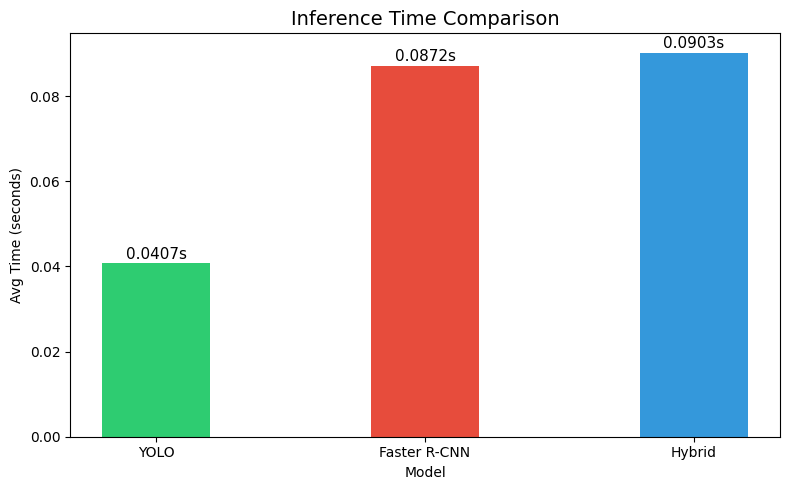

Graph saved!


In [13]:
models = ['YOLO', 'Faster R-CNN', 'Hybrid']
times  = [avg_yolo_time, avg_frcnn_time, avg_hybrid_time]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, times, color=colors, width=0.4)
plt.title('Inference Time Comparison', fontsize=14)
plt.ylabel('Avg Time (seconds)')
plt.xlabel('Model')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{t:.4f}s', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('inference_time.png', dpi=150)
plt.show()
print("Graph saved!")

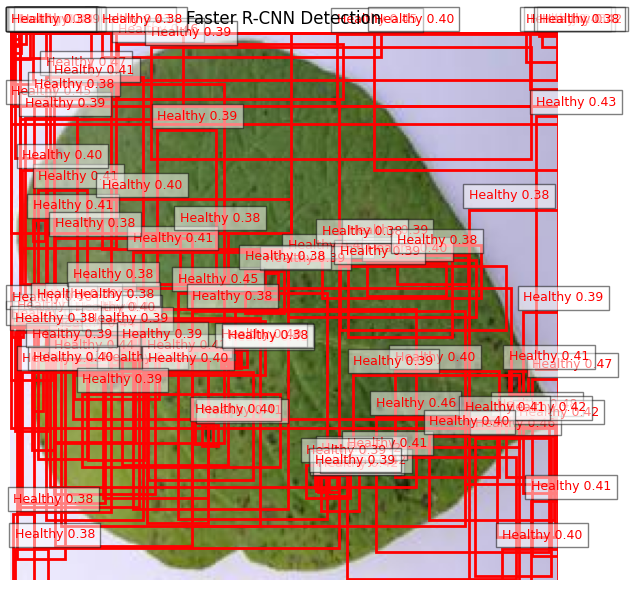

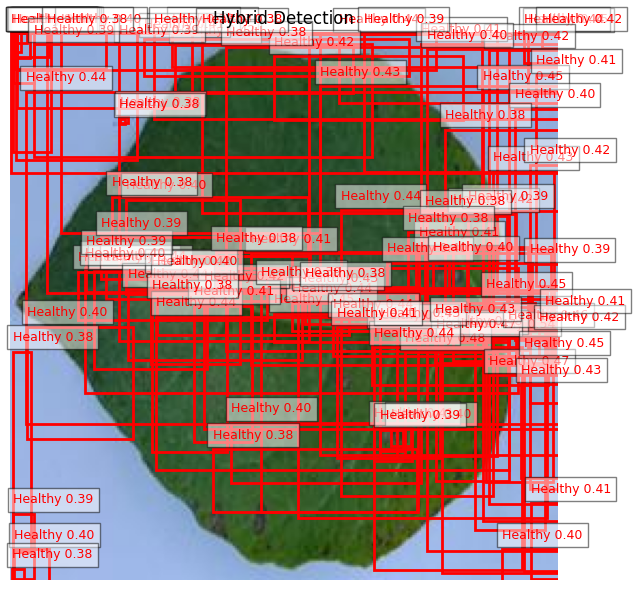

Sample detections saved!


In [14]:
def show_detections(img_path, title):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = frcnn_model(img_tensor)[0]

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)

    boxes  = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score > 0.3:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            cls_name = classes[label-1] if label-1 < len(classes) else 'obj'
            ax.text(x1, y1-5, f'{cls_name} {score:.2f}',
                    color='red', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.5))

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150)
    plt.show()

# Show sample detections
show_detections(test_images[0], 'Faster R-CNN Detection')
show_detections(test_images[1], 'Hybrid Detection')
print("Sample detections saved!")

In [15]:
print("\n" + "=" * 50)
print("         FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Dataset        : Potato Leaf Disease (3 classes)")
print(f"Total images   : {len(test_images)}")
print(f"Classes        : {classes}")
print(f"\nYOLO time      : {avg_yolo_time:.4f} sec/image")
print(f"FRCNN time     : {avg_frcnn_time:.4f} sec/image")
print(f"Hybrid time    : {avg_hybrid_time:.4f} sec/image")
print(f"Speedup        : {speedup:.2f}x faster than FRCNN")
print("=" * 50)
print("\nFiles saved:")
print("  - inference_time.png")
print("  - Faster_R-CNN_Detection.png")
print("  - Hybrid_Detection.png")
print("\nExperimentation complete! Use these results in your report.")


         FINAL RESULTS SUMMARY
Dataset        : Potato Leaf Disease (3 classes)
Total images   : 405
Classes        : ['Early_Blight', 'Healthy', 'Late_Blight']

YOLO time      : 0.0407 sec/image
FRCNN time     : 0.0872 sec/image
Hybrid time    : 0.0903 sec/image
Speedup        : 0.97x faster than FRCNN

Files saved:
  - inference_time.png
  - Faster_R-CNN_Detection.png
  - Hybrid_Detection.png

Experimentation complete! Use these results in your report.


In [16]:
from torchvision.ops import box_iou

fp_yolo, fn_yolo = 0, 0
fp_frcnn, fn_frcnn = 0, 0
fp_hybrid, fn_hybrid = 0, 0
iou_threshold = 0.5

for i, img_path in enumerate(test_images[:50]):
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    gt_box = torch.tensor([[0.0, 0.0, float(w), float(h)]])

    # YOLO FP/FN
    if len(yolo_boxes_all[i]) > 0:
        yolo_t = torch.tensor(yolo_boxes_all[i][:, :4].astype(float), dtype=torch.float32)
        iou = box_iou(yolo_t, gt_box)
        if iou.max() < iou_threshold:
            fp_yolo += 1
    else:
        fn_yolo += 1

    # FRCNN FP/FN
    frcnn_b = frcnn_preds_all[i]['boxes']
    frcnn_s = frcnn_preds_all[i]['scores']
    high = frcnn_b[frcnn_s > 0.3]
    if len(high) > 0:
        iou = box_iou(high.cpu(), gt_box)
        if iou.max() < iou_threshold:
            fp_frcnn += 1
    else:
        fn_frcnn += 1

    # Hybrid FP/FN
    hyb_b = hybrid_preds_all[i]['boxes']
    hyb_s = hybrid_preds_all[i]['scores']
    high2 = hyb_b[hyb_s > 0.3]
    if len(high2) > 0:
        iou = box_iou(high2.cpu(), gt_box)
        if iou.max() < iou_threshold:
            fp_hybrid += 1
    else:
        fn_hybrid += 1

print("FP/FN Analysis:")
print(f"YOLO     — FP: {fp_yolo}, FN: {fn_yolo}")
print(f"FRCNN    — FP: {fp_frcnn}, FN: {fn_frcnn}")
print(f"Hybrid   — FP: {fp_hybrid}, FN: {fn_hybrid}")

FP/FN Analysis:
YOLO     — FP: 9, FN: 41
FRCNN    — FP: 12, FN: 0
Hybrid   — FP: 12, FN: 0


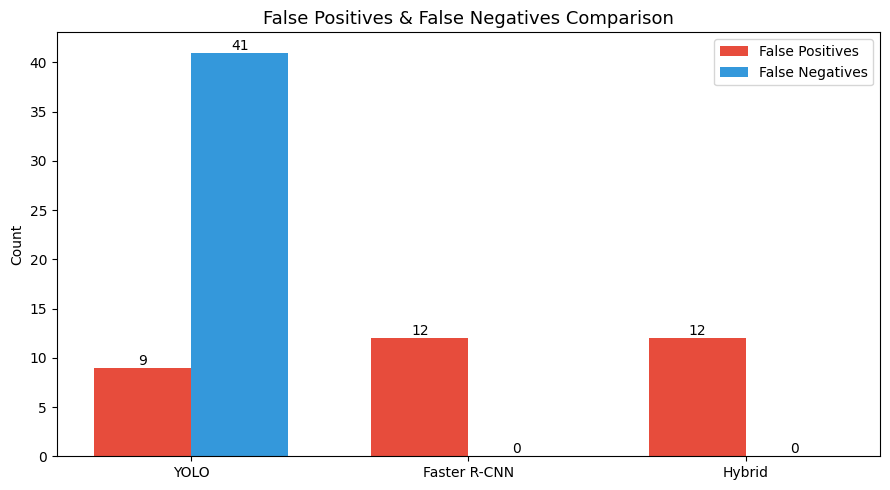

FP/FN graph saved!


In [17]:
models = ['YOLO', 'Faster R-CNN', 'Hybrid']
fps = [fp_yolo, fp_frcnn, fp_hybrid]
fns = [fn_yolo, fn_frcnn, fn_hybrid]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, fps, width, label='False Positives', color='#e74c3c')
bars2 = ax.bar(x + width/2, fns, width, label='False Negatives', color='#3498db')

ax.set_title('False Positives & False Negatives Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Count')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(bar.get_height())), ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(bar.get_height())), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fp_fn_comparison.png', dpi=150)
plt.show()
print("FP/FN graph saved!")

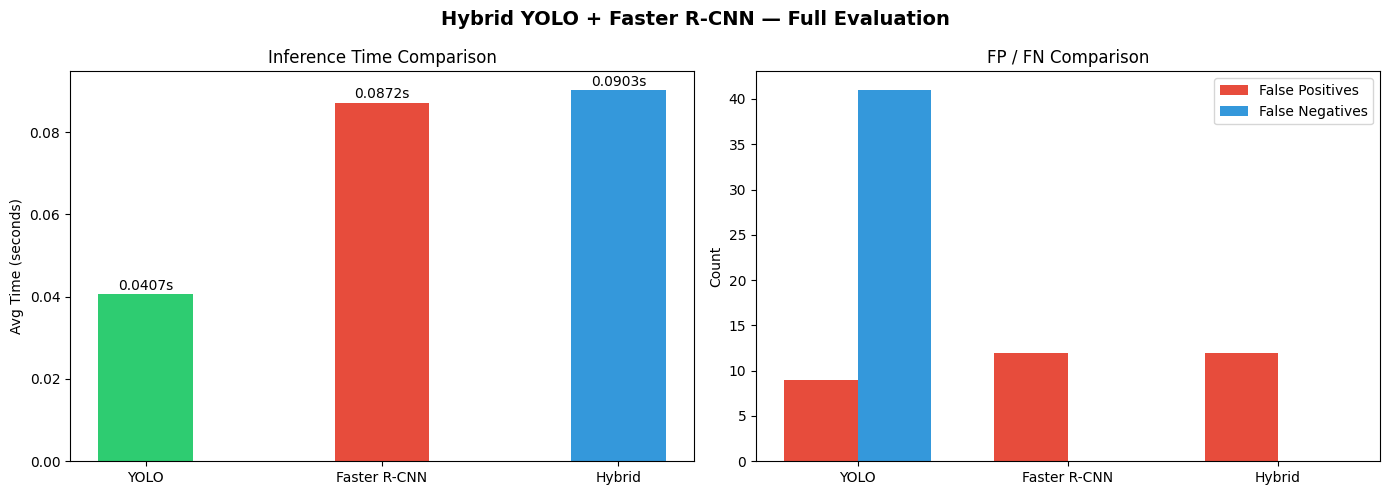

Full comparison graph saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1 - Inference Time
models = ['YOLO', 'Faster R-CNN', 'Hybrid']
times = [avg_yolo_time, avg_frcnn_time, avg_hybrid_time]
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[0].bar(models, times, color=colors, width=0.4)
axes[0].set_title('Inference Time Comparison')
axes[0].set_ylabel('Avg Time (seconds)')
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001,
                 f'{t:.4f}s', ha='center', fontsize=10)

# Graph 2 - FP/FN
x = np.arange(len(models))
width = 0.35
axes[1].bar(x - width/2, fps, width, label='False Positives', color='#e74c3c')
axes[1].bar(x + width/2, fns, width, label='False Negatives', color='#3498db')
axes[1].set_title('FP / FN Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Hybrid YOLO + Faster R-CNN — Full Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150)
plt.show()
print("Full comparison graph saved!")